In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import gymnasium as gym
import os

import numpy as np
from tensorboard.backend.event_processing import event_accumulator
from pathlib import Path
from stable_baselines3 import DQN as SB3DQN
from highway.scripts.run import eval_agent, run_one_episode
from highway.scripts.environment import get_env, ConfigType
from highway.scripts.utils.agents import SB3GreedyAgent
from highway.scripts.utils.plotting import (
    plot_losses,
    plot_rewards_lengths,
    plot_train_rewards_lengths,
)
from highway.scripts.utils.statistics import compute_confidence_interval

# CNN_DQN ANLYSIS

In [22]:
OUTPUT_ROOT = Path("outputs_cnn_dqn")
EVAL_CURVES_PATH = OUTPUT_ROOT / "eval_curves.npz"
EVAL_LOGS_PATH = OUTPUT_ROOT / "eval_logs" / "evaluations.npz"
BEST_MODEL_PATH = OUTPUT_ROOT / "best_model" / "best_model.zip"
REF_BEST_MODEL_PATH = OUTPUT_ROOT / "REF_BEST.zip"
FINAL_MODEL_PATH = OUTPUT_ROOT / "model.zip"
TB_ROOT = OUTPUT_ROOT / "tb"
EVENT_PATH = TB_ROOT / "cnn_dqn_20260412_225615_1" / "events.out.tfevents.1776027382.LAPTOP-DOH1GCOI.2816.0"
eval_data = np.load(EVAL_CURVES_PATH)
timesteps = eval_data["timesteps"]
mean_rewards = eval_data["mean_rewards"]
mean_ep_lengths = eval_data["mean_ep_lengths"]

In [23]:
event_file = EVENT_PATH
ea = event_accumulator.EventAccumulator(str(event_file))
ea.Reload()
print("Available scalar tags in tensor board:", ea.Tags().get("scalars", []))

Available scalar tags in tensor board: ['rollout/exploration_rate', 'time/fps', 'train/learning_rate', 'train/loss', 'eval/mean_ep_length', 'eval/mean_reward']


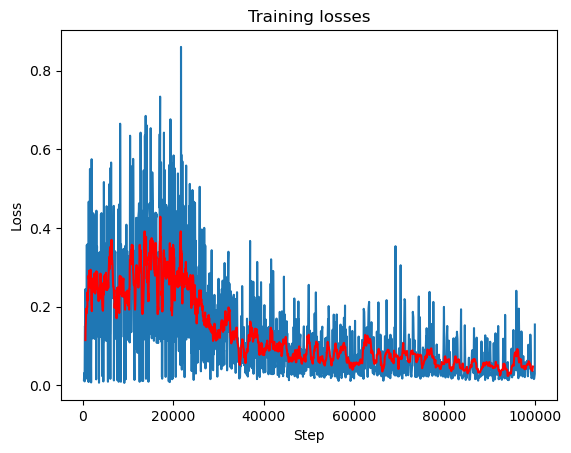

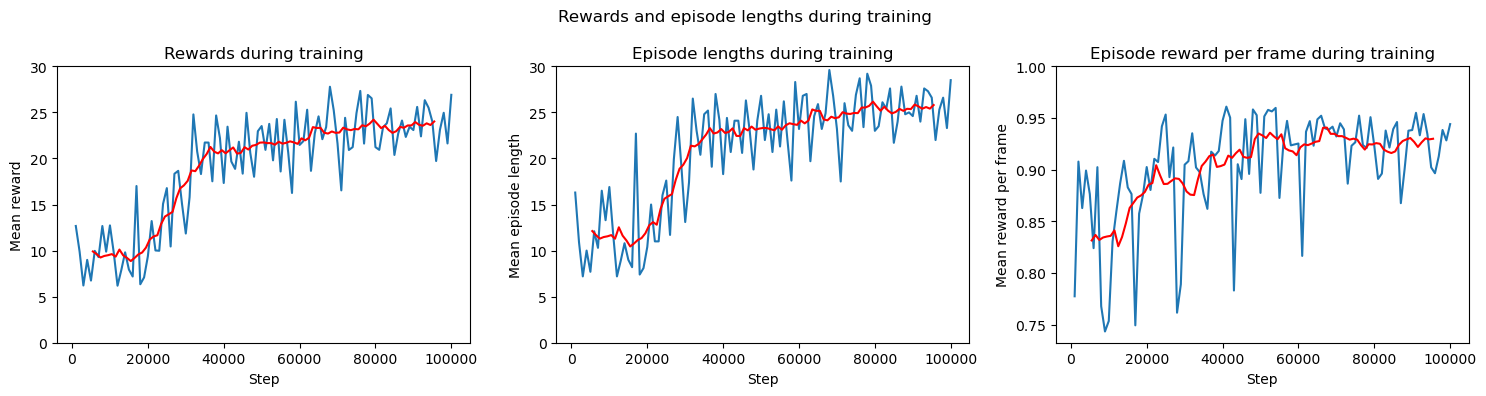

In [24]:
events = ea.Scalars("train/loss")
values = np.array([event.value for event in events], dtype=float)
plot_losses(values, nb_smoothen=10, title="Training losses", x_values=[event.step for event in events])
plot_train_rewards_lengths(mean_rewards, mean_ep_lengths, nb_smoothen=10, x_values=timesteps)

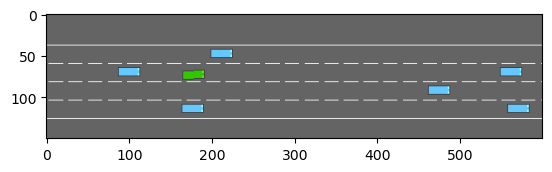

Episode reward=29.54, length=30


In [26]:
sb3_model = SB3DQN.load(
    str(BEST_MODEL_PATH),
    device="cpu",
    custom_objects={"buffer_size": 1},
)
agent = SB3GreedyAgent(sb3_model)
env_CNN = get_env(config_type=ConfigType.TEST_CNN)
reward, length = run_one_episode(env_CNN, agent, display=True, make_deep_copy=False)

In [29]:
eval_seeds = list(range(50))
rewards, lengths = eval_agent(env_CNN, agent, seeds=eval_seeds, show_progress=True, make_deep_copy=False)

Evaluating: 100%|██████████| 50/50 [07:39<00:00,  9.20s/ep]


In [ ]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 22.93 ± 2.32 (95% CI: [20.61, 25.26])
Length: 24.82 ± 2.39 (95% CI: [22.43, 27.21])


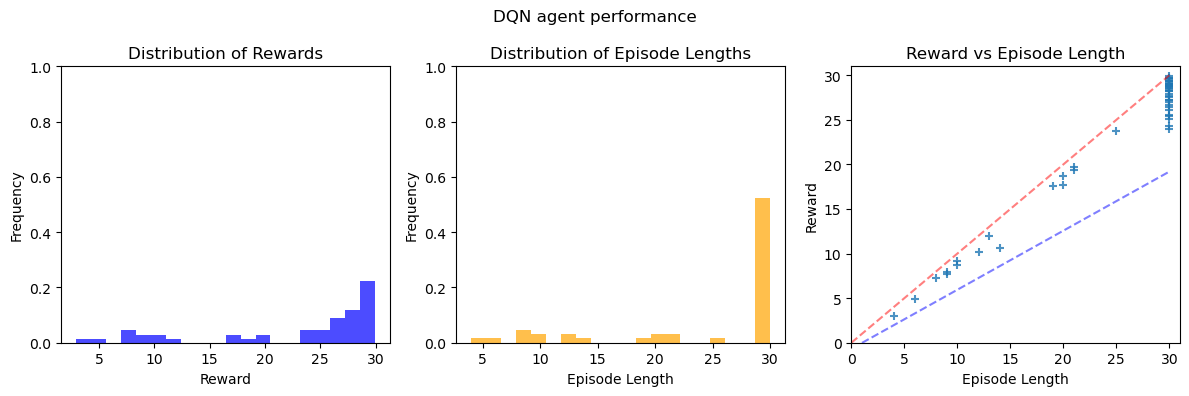

In [ ]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")